## **Monthly MC Ridership Trend**

In [15]:
import sys
import os
import pandas as pd
import numpy as np
import importlib
import seaborn as sns
import matplotlib.pyplot as plt

# stop id and names
STOP_NAMES = {
    37: 'Doan Hall',
    94: 'Carmack 5A',
    95: 'Carmack 5B',
    401: 'University Hospital',
    403: 'Carmack 2',
    404: 'Carmack 3'
}

# Observed university holidays for 2026
# NOTE: Observed date is not always the same as actual date
UNIVERSITY_HOLIDAYS = [
    '2026-01-01',  # New Year's Day
    '2026-01-19',  # Martin Luther King Jr. Day
    '2026-05-25',  # Memorial Day
    '2026-06-19',  # Juneteenth
    '2026-07-03',  # Independence Day (observed)
    '2026-09-07',  # Labor Day
    '2026-11-11',  # Veterans Day
    '2026-11-26',  # Thanksgiving
    '2026-11-27',  # Columbus Day (observed)
    '2026-12-24',  # Presidents' Day (observed)
    '2026-12-25'   # Christmas
]

In [14]:
# go up one level from notebook folder
sys.path.append(os.path.abspath(".."))

from modules import med_center_dashboard as mcd
importlib.reload(mcd)

data_dir = "K:/AP/TTM/Data/WMC_Dashboard/busstate_cleaned"

# month and date dict
MONTH = 'JAN'
YEAR = 2026

# set dir to save cleaned files to 
# repo_dir = "K:/AP/TTM/Data/WMC_Dashboard/analysis_data/peak_hours_cleaned"

df = mcd.process_mc_busstate(year=YEAR, month=MONTH, current_dir=data_dir)

In [29]:
# Cut down df to necessary columns
mc_df = df[['DATE', 'STOP_ID', 'BOARDINGS', 'ALIGHTINGS', 'RUN_ID', 'ARRIVAL', 'DEPARTURE', 'DWELL', 'HOUR', 'MINUTE']].copy()
mc_df.columns = mc_df.columns.str.lower()

# map for inbound vs outbound stops
DIRECTION_MAP = {
    37: 'Outbound',
    94: 'Inbound',
    95: 'Inbound',
    401: 'Outbound',
    403: 'Inbound',
    404: 'Inbound'
}

# Parse time-related columns
mc_df['arrival'] = pd.to_datetime(mc_df['arrival'])
mc_df['departure'] = pd.to_datetime(mc_df['departure'])
mc_df['dwell'] = pd.to_timedelta(mc_df['dwell'], unit='s')
mc_df['time'] = pd.to_datetime(mc_df['date'].astype(str) + ' ' + mc_df['arrival'].dt.time.astype(str))

mc_df.sort_values(by='time', inplace=True)

# Normalize numeric dtypes
mc_df['stop_id'] = mc_df['stop_id'].astype(int)
mc_df['boardings'] = mc_df['boardings'].astype(int)
mc_df['alightings'] = mc_df['alightings'].astype(int)
mc_df['run_id'] = mc_df['run_id'].astype(int)

# Add convenience columns
mc_df['stop_name'] = mc_df['stop_id'].map(STOP_NAMES)
mc_df['weekday'] = mc_df['date'].dt.day_name()  # in case weekday-related patterns surface
mc_df['dwell_sec'] = mc_df['dwell'].dt.total_seconds()
mc_df['weekday_num'] = mc_df['date'].dt.weekday  # Monday=0, Sunday=6
mc_df['direction'] = mc_df['stop_id'].map(DIRECTION_MAP)

# print total boardings before dropping sat/sun for month sanity check
# total_boardings = mc_df['boardings'].sum()
# print(f'{total_boardings} total boardings')

# Remove weekend rows currently out of scope
mc_df = mc_df[mc_df['weekday'] != 'Saturday']
mc_df = mc_df[mc_df['weekday'] != 'Sunday']

# Remove university holidays
mc_df = mc_df[~mc_df['date'].dt.normalize().isin(pd.to_datetime(UNIVERSITY_HOLIDAYS))]

In [30]:
# Shape and data check
print(f'Records : {len(mc_df)}')
print(f'Date range : {mc_df["date"].min().date()}  - {mc_df["date"].max().date()}')
print(f'Unique dates : {mc_df["date"].dt.date.nunique()}')
print(mc_df.dtypes)
mc_df.head(3)

Records : 34964
Date range : 2026-01-02  - 2026-01-30
Unique dates : 20
date            datetime64[us]
stop_id                  int64
boardings                int64
alightings               int64
run_id                   int64
arrival         datetime64[us]
departure       datetime64[us]
dwell          timedelta64[us]
hour                     int32
minute                   int32
time            datetime64[us]
stop_name                  str
weekday                    str
dwell_sec              float64
weekday_num              int32
direction                  str
dtype: object


,date,stop_id,boardings,alightings,run_id,arrival,departure,dwell,hour,minute,time,stop_name,weekday,dwell_sec,weekday_num,direction
10458,2026-01-02,403,0,0,1502,1900-01-01 00:21:11,1900-01-01 00:24:31,0 days 00:03:20,0,21,2026-01-02 00:21:11,Carmack 2,Friday,200.0,4,Inbound
10459,2026-01-02,404,0,0,1502,1900-01-01 00:25:21,1900-01-01 00:25:57,0 days 00:00:36,0,25,2026-01-02 00:25:21,Carmack 3,Friday,36.0,4,Inbound
10460,2026-01-02,94,0,0,1502,1900-01-01 00:26:53,1900-01-01 00:27:00,0 days 00:00:07,0,26,2026-01-02 00:26:53,Carmack 5A,Friday,7.0,4,Inbound


In [31]:
# Missing data check
missing = mc_df.isnull().sum()
missing

date           0
stop_id        0
boardings      0
alightings     0
run_id         0
arrival        0
departure      0
dwell          0
hour           0
minute         0
time           0
stop_name      0
weekday        0
dwell_sec      0
weekday_num    0
direction      0
dtype: int64

In [32]:
# Data ranges and distributions check
mc_df.describe()

,date,stop_id,boardings,alightings,run_id,arrival,departure,dwell,hour,minute,time,dwell_sec,weekday_num
count,34964,34964.000000,34964.000000,34964.000000,34964.000000,34964,34964,34964,34964.000000,34964.000000,34964,34964.000000,34964.000000
mean,2026-01-16 10:33:50.431300,247.043416,2.964621,2.945372,1504.367092,1900-01-01 13:18:39.355623,1900-01-01 13:19:46.436564,0 days 00:01:07.080940,12.816783,29.159593,2026-01-16 23:52:29.786923,67.080940,2.215279
min,2026-01-02 00:00:00,37.000000,0.000000,0.000000,1501.000000,1900-01-01 00:00:00,1900-01-01 00:00:06,0 days 00:00:00,0.000000,0.000000,2026-01-02 00:21:11,0.000000,0.000000
25%,2026-01-08 00:00:00,94.000000,0.000000,0.000000,1502.000000,1900-01-01 07:39:46.500000,1900-01-01 07:40:58.750000,0 days 00:00:34,7.000000,14.000000,2026-01-08 19:07:45.500000,34.000000,1.000000
50%,2026-01-15 00:00:00,401.000000,1.000000,1.000000,1504.000000,1900-01-01 14:15:36,1900-01-01 14:16:37,0 days 00:00:50,14.000000,29.000000,2026-01-15 19:13:14,50.000000,2.000000
75%,2026-01-23 00:00:00,403.000000,4.000000,4.000000,1506.000000,1900-01-01 18:19:44,1900-01-01 18:20:52.750000,0 days 00:01:24,18.000000,45.000000,2026-01-23 19:52:08.250000,84.000000,4.000000
max,2026-01-30 00:00:00,404.000000,65.000000,70.000000,1514.000000,1900-01-01 23:59:57,1900-01-01 23:59:59,0 days 00:12:58,23.000000,59.000000,2026-01-30 23:59:43,778.000000,4.000000
std,NaN,165.706697,5.122221,4.837773,2.907233,NaN,NaN,0 days 00:00:51.751885,6.046527,17.494673,NaN,51.751886,1.401114



---

### **Total Ridership Trends:**

In [33]:
# total boardings, total active days, average daily boardings in month/year
total_boardings = int(mc_df['boardings'].sum())

total_service_days = mc_df["date"].dt.date.nunique()

average_daily_boardings = total_boardings / total_service_days

print(f"Total boardings in {MONTH}/{YEAR}: {total_boardings}")
print(f"Total active service days in {MONTH}/{YEAR}: {total_service_days}")
print(f"Average daily boardings in {MONTH}/{YEAR}: {average_daily_boardings:.0f}")


Total boardings in JAN/2026: 103655
Total active service days in JAN/2026: 20
Average daily boardings in JAN/2026: 5183


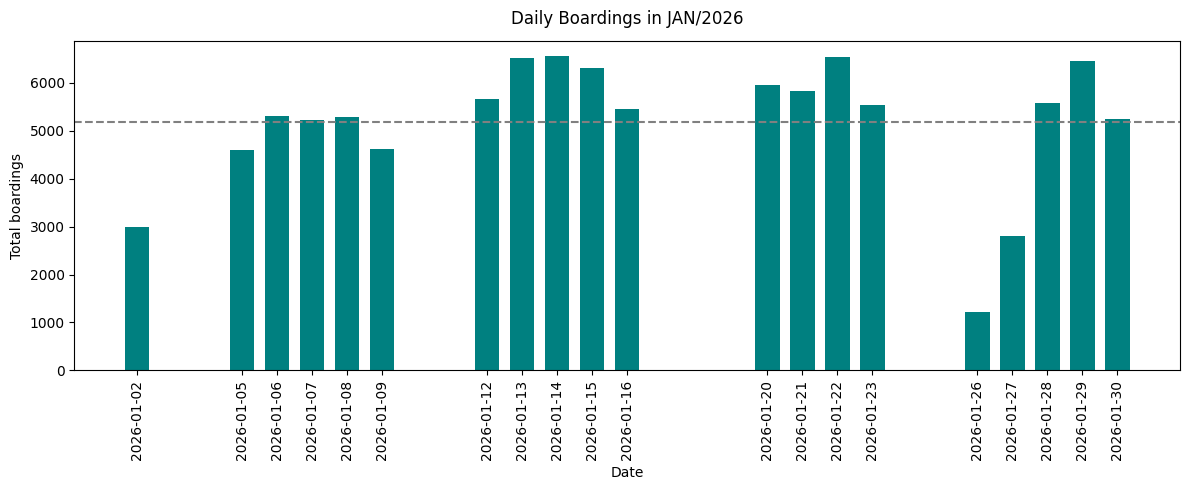

In [34]:
# plot the daily boardings for each day in the month to see variation in day to day
daily_boardings = (
    mc_df.groupby('date')['boardings']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(daily_boardings['date'], daily_boardings['boardings'], color='teal', width=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('Total boardings')
ax.set_title(f'Daily Boardings in {MONTH}/{YEAR}', pad=12)
ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=10))

ax.axhline(average_daily_boardings, linestyle='--', linewidth=1.5, color='grey', label='Average Daily Boardings')

ax.set_xticks(daily_boardings['date'])
ax.set_xticklabels(daily_boardings['date'].dt.strftime('%Y-%m-%d'))
plt.xticks(rotation=90)
plt.tight_layout()
# plt.savefig(f'1_daily_boardings_{MONTH}_{YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
daily_boardings

,date,boardings
0,2026-01-02,2996
1,2026-01-05,4597
2,2026-01-06,5312
3,2026-01-07,5230
4,2026-01-08,5282
5,2026-01-09,4625
6,2026-01-12,5657
7,2026-01-13,6508
8,2026-01-14,6547
9,2026-01-15,6309
